# UNIVERSIDAD ICESI
# MAESTRIA EN  IA APLICADA
# Trabajo 2
## Nombres:

#### Angelica Maria Mayor
#### Diego Agudelo
#### Freddy Mauricio Gutierrez
#### Carlos Alberto Martinez Ramirez
#### Wilman Quiñonez


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion2/2-nlp-with-lstm.ipynb)

En este notebook implementaremos un clasificador de noticias en español utilizando la arquitectura de red LSTM. La idea es tener un punto de referencia para comparar cuando observemos la parte de transformers, por lo que utilizaremos el mismo dataset y tarea de ejemplo. Utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

El dataset contiene lo siguiente:

**review_id** → ID único de la reseña.

**reviewer_id** → ID del usuario que dejó la reseña.

**review_title** → Título de la reseña.

**review_body** → Texto completo de la reseña.

**star_rating** → Puntuación otorgada (1–5 estrellas).

**language** → Idioma de la reseña (en este caso siempre "en").

**product_category** → Categoría del producto (ej: libros, electrónica, etc.).

**review_date** → Fecha en que se dejó la reseña.


📐 Tamaño aproximado El dataset completo multilingüe contiene más de 200 millones de reseñas en distintos idiomas. La versión en inglés ("en") sigue siendo enorme: millones de reseñas en varias categorías de productos.

#### Referencias

- [Long Short-Term Memory](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory#fullTextFileContent)

In [4]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

/tmp/ipython-input-2396000874.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [5]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

## Dataset   

In [6]:
from datasets import load_dataset

# Cargar el split de entrenamiento en inglés, versión Parquet (mirror)
dataset = load_dataset("neonwatty/amazon_reviews_multi", "en", split="train")
dataset


Dataset({
    features: ['review_title', 'review_body', 'review_id', 'stars'],
    num_rows: 200000
})

In [7]:
dataset[1]

{'review_title': 'Not use able',
 'review_body': 'the cabinet dot were all detached from backing... got me',
 'review_id': 'en_0690095',
 'stars': 1}

Se realiza el analisis descriptivo:



In [8]:
import numpy as np

# Calculamos la longitud en tokens (palabras simples separadas por espacios)
text_lengths = [len(row['review_body'].split()) for row in dataset]

print(f"Texto más corto: {min(text_lengths)} tokens")
print(f"Texto más largo: {max(text_lengths)} tokens")
print(f"Longitud promedio: {np.mean(text_lengths):.2f} tokens")

# Percentiles
for p in [50, 75, 90, 95, 99]:
    print(f"P{p}: {np.percentile(text_lengths, p)} tokens")


Texto más corto: 1 tokens
Texto más largo: 769 tokens
Longitud promedio: 34.11 tokens
P50: 24.0 tokens
P75: 44.0 tokens
P90: 72.0 tokens
P95: 96.0 tokens
P99: 165.0 tokens


In [9]:
import plotly.express as px

# Suponiendo que ya calculaste text_lengths así:
# text_lengths = [len(row['review_body'].split()) for row in dataset]

# Crear boxplot horizontal
fig = px.box(
    x=text_lengths,  # eje horizontal con las longitudes
    orientation="h",
    labels={"x": "Longitud de reseña (tokens)"},
    title="Distribución de longitudes de reseñas (tokens)"
)

fig.show()


Se analizaron 200,000 reseñas.

La longitud promedio es de 34 tokens, con una desviación estándar también de ~34 → hay bastante variabilidad.

La reseña más corta tiene 1 token y la más larga llega hasta 769 tokens.

Percentiles:

25% de las reseñas tienen ≤ 12 tokens.

50% (mediana) tienen ≤ 24 tokens.

75% tienen ≤ 44 tokens.

In [10]:
import pandas as pd

# Convertir lista a Series de Pandas
text_lengths_series = pd.Series(text_lengths)

# Usar describe()
print(text_lengths_series.describe())


count    200000.000000
mean         34.114000
std          34.201068
min           1.000000
25%          12.000000
50%          24.000000
75%          44.000000
max         769.000000
dtype: float64


Se calcula las palabras unicas en el dataset, que sera utilizado mas adelante

In [11]:
from collections import Counter

token_counts = Counter()

for row in dataset:   # dataset es el HuggingFace Dataset
    text = (row['review_title'] + " " + row['review_body']).lower()
    tokens = text.split()   # o tu propio tokenizador si ya lo definiste
    token_counts.update(tokens)

# número de palabras únicas
num_unique_words = len(token_counts)
print("Palabras únicas en el dataset:", num_unique_words)

# ejemplo: mostrar algunas
print(list(token_counts.items())[:20])


Palabras únicas en el dataset: 137303
[("i'll", 1705), ('spend', 1018), ('twice', 1093), ('the', 367051), ('amount', 1407), ('of', 95069), ('time', 12173), ('boxing', 35), ('up', 19119), ('whole', 1895), ('useless', 864), ('thing', 4692), ('and', 200517), ('send', 2083), ('it', 181608), ('back', 9453), ('with', 53611), ('a', 180143), ('1-star', 12), ('review', 2154)]


## Tokenizador

Este código construye un vocabulario limitado (40k palabras) a partir de las reseñas, reservando [PAD] y [UNK].

[PAD] (padding): se usa para rellenar las secuencias más cortas y que todas tengan la misma longitud.

[UNK] (unknown): representa palabras fuera del vocabulario (OOV) que no fueron incluidas en las 40k más frecuentes.

In [12]:
import re
from collections import Counter

def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
    return text.strip().split()

# Construimos el vocabulario a partir de conjunto de datos.
token_counts = Counter()
for text in dataset["review_body"]:
    token_counts.update(simple_tokenizer(text))

# 50k-2 porque necesitamos reservar espacio para los dos tokens especiales
top_n_tokens = list(token_counts.keys())[:40000-2]
vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens:
    vocab[token] = len(vocab)

def tokenize_text(text, max_length=50):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

In [13]:
print(f"Vocabulario: {len(vocab)} tokens")
print("Primeros 15 tokens:")
print(f"{top_n_tokens[:15]}")
print("15 tokens de en medio:")
print(f"{top_n_tokens[1000:1015]}")
print("Últimos 15 tokens:")
print(f"{top_n_tokens[-15:]}")

Vocabulario: 40000 tokens
Primeros 15 tokens:
['arrived', 'broken', 'manufacturer', 'defect', 'two', 'of', 'the', 'legs', 'base', 'were', 'not', 'completely', 'formed', 'so', 'there']
15 tokens de en medio:
['five', 'minutes', 'compatible', 'active', 'land', 'dial', 'tone', 'bottles', 'intention', 'mixing', 'essential', 'oils', 'spray', 'leak', 'frequently']
Últimos 15 tokens:
['inadvisable', 'thinsulate', 'unmasking', 'kylo', 'remoter', 'littke', 'opp', 'bayliner', 'marches', 'guernsey', 'propylene', 'glycol', 'scenic', 'catheters', 'heartland']


In [14]:
tokenized = tokenize_text("hello active", max_length=8)
tokenized

[3780, 1005, 0, 0, 0, 0, 0, 0]

In [15]:
id_2_token = {v: k for k, v in vocab.items()}
[id_2_token[token] for token in tokenized]

['hello', 'active', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

## Pytorch

In [16]:
import numpy as np

dict(enumerate(np.unique(dataset[:]['stars'])))

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5}

Este código prepara reseñas de Amazon para modelos de PyTorch, convirtiendo el texto en secuencias de tokens y las estrellas en etiquetas numéricas.
Esto es lo que necesitas para luego entrenar una LSTM

In [17]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

class amazon_dataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 128):
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['stars'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['review_body'], self.dataset[index]['stars']
        y = self.class_2_id_map[y]
        data = {'input_ids': torch.tensor(self.tokenizer(text, max_length=self.seq_length))}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

In [18]:
max_len = 128
data_amazon = amazon_dataset(tokenize_text, dataset, seq_length=max_len)
assert len(data_amazon) == len(dataset)

In [19]:
data_amazon[1]

{'input_ids': tensor([ 8, 86, 87, 11, 88, 89, 90, 91, 51, 74,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0]),
 'y': tensor(0)}

Este código toma el dataset de reseñas de Amazon (data_amazon), lo divide en conjuntos de entrenamiento, validación y prueba de forma estratificada, y genera los correspondientes DataLoaders que se utilizan para alimentar el modelo durante las fases de entrenamiento, validación y evaluación. Lo cual lo hace estratificado para no tener ningun incovenientes de balanceo.

In [20]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

# 1) saca las labels del dataset PyTorch (data_amazon[i] -> dict con 'y')
labels = [int(data_amazon[i]['y']) for i in range(len(data_amazon))]
idx = list(range(len(data_amazon)))

# 2) split train vs temp (val+test) estratificado
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, labels, test_size=0.2, random_state=42, stratify=labels
)

# 3) split temp a val/test estratificado
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

train_dataset = Subset(data_amazon, idx_train)
val_dataset   = Subset(data_amazon, idx_val)
test_dataset  = Subset(data_amazon, idx_test)

batch_size = 128 if IN_COLAB else 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)


In [21]:
train_loader.dataset[0]


{'input_ids': tensor([ 507,  451,   64, 1391, 4130,  103,    8, 1182,   23,  526,  331,   53,
         1467,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]),
 'y': tensor(4)}

### Modelo BASELINE
Se construye un modelo baseline utilizando representaciones tradicionales (Word2Vec y TF-IDF) con el objetivo de establecer un punto de comparación y evaluar posteriormente si una arquitectura basada en LSTM puede ofrecer un mejor desempeño


[Modelo de multinomial-TF-IDF](https://)

Ejemplo: Cute and durable. Cute, good quality, packaged differently than the ones I’ve seen in stores. ... 4
Tamaños: 160000 20000 20000

TF-IDF + Logistic Regression | Val Accuracy: 0.6050

              precision    recall  f1-score   support

           0     0.6687    0.7010    0.6845      4000
           1     0.4987    0.4935    0.4961      4000
           2     0.5095    0.4808    0.4947      4000
           3     0.5892    0.5615    0.5750      4000
           4     0.7399    0.7885    0.7634      4000

    accuracy                         0.6050     20000
   macro avg     0.6012    0.6050    0.6027     20000
weighted avg     0.6012    0.6050    0.6027     20000



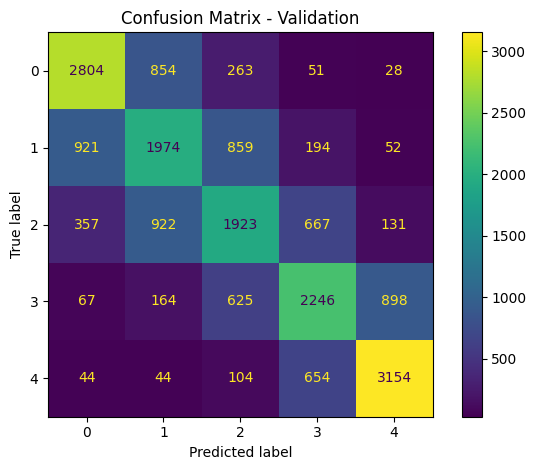

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def _unwrap_base_dataset(ds):
    """Desciende por atributos .dataset hasta llegar al dataset base (HF Dataset)."""
    base = ds
    # ds puede ser tu CustomDataset envuelto por Subset; vamos bajando mientras exista .dataset
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    """
    Convierte un torch.utils.data.Subset -> (X, y) usando:
      - y: del propio subset[i]['y'] (ya en 0..4)
      - texto: del dataset base (HF) vía subset.indices -> row['review_title']/'review_body'].
    """
    # 1) indices globales a los que apunta el Subset
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")

    base_custom = subset.dataset            # tu CustomDataset
    base_source = _unwrap_base_dataset(base_custom)  # HF Dataset u otro contenedor con texto

    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))

    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]

        # y lo tomamos del subset ya procesado (0..4, torch.long)
        y_i = int(subset[i]["y"])

        # texto crudo desde el dataset base
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            # fallback por si el dataset usa otra clave (por ej. 'text')
            text = str(row.get("text", "") or "")

        X.append(text)
        y.append(y_i)
    return X, y

# ---- Construye X,y para train/val/test ----
X_train, y_train = subset_to_xy_from_base(train_dataset)   # puedes pasar max_n=20000 para ir más rápido
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

print("Ejemplo:", X_train[0][:120], "...", y_train[0])
print("Tamaños:", len(X_train), len(X_val), len(X_test))

# ---- TF-IDF ----
vec = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
    lowercase=True
)
Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)

# ---- Clasificador (CPU, rápido) ----
clf = LogisticRegression(
    max_iter=300,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)
clf.fit(Xtr, y_train)

# ---- Métricas ----
pred_val = clf.predict(Xva)
acc_val = accuracy_score(y_val, pred_val)
print(f"\nTF-IDF + Logistic Regression | Val Accuracy: {acc_val:.4f}\n")
print(classification_report(y_val, pred_val, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation")
plt.tight_layout()
plt.show()



Se entrenó un modelo TF-IDF + Regresión Logística con 160k reseñas de entrenamiento y se evaluó en 20k de validación. El modelo logró una accuracy del 60.5%.

El mejor desempeño está en la clase 4 estrellas (precisión 0.74, recall 0.79, f1=0.76).

También destaca la clase 0 estrellas con f1≈0.68.

Las clases 1 y 2 estrellas son las más difíciles de distinguir (f1≈0.49).

En general, el modelo diferencia bien opiniones muy negativas o muy positivas, pero confunde las reseñas de valoración intermedia.

Modelo Lightgbm-TF-IDF

Ejemplo: Cute and durable. Cute, good quality, packaged differently than the ones I’ve seen in stores. ... 4
Tamaños: 160000 20000 20000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 225.611004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1426796
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 38577
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.06789	valid_0's multi_error: 0.4356
[100]	valid_0's multi_logloss: 0.987584	valid_0's multi_error: 0.41655
[150]	valid_0's multi_logloss: 0.954329	valid_0's multi_error: 0.4077
[200]	valid_0's multi_log

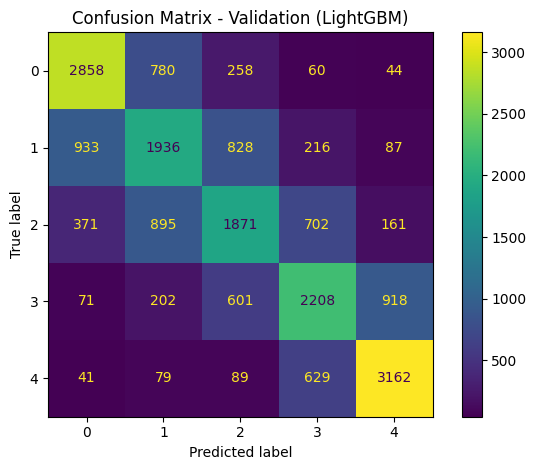

TF-IDF + LightGBM | Test Accuracy: 0.6040


In [ ]:
# pip install lightgbm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

# ================= Helpers para extraer X,y de tus Subset =================
def _unwrap_base_dataset(ds):
    """Desciende por atributos .dataset hasta llegar al dataset base (HF Dataset)."""
    base = ds
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    """
    Convierte un torch.utils.data.Subset -> (X, y).
      y: subset[i]['y'] (0..C-1)
      texto: del dataset base (HF) vía subset.indices -> 'review_title' + 'review_body'
    """
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")

    base_custom = subset.dataset
    base_source = _unwrap_base_dataset(base_custom)

    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))

    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]
        y_i = int(subset[i]["y"])
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            text = str(row.get("text", "") or "")
        X.append(text)
        y.append(y_i)
    return X, y

# ================= Construcción de X,y (mismo flujo que tu código) =================
X_train, y_train = subset_to_xy_from_base(train_dataset)
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

print("Ejemplo:", X_train[0][:120], "...", y_train[0])
print("Tamaños:", len(X_train), len(X_val), len(X_test))

# ================= TF-IDF (igual que antes) =================
vec = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
    lowercase=True
)
Xtr = vec.fit_transform(X_train)   # CSR
Xva = vec.transform(X_val)
Xte = vec.transform(X_test)

# ================= LightGBM (multiclase) =================
num_classes = len(np.unique(y_train))
clf = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,   # opcional, el wrapper puede inferirlo
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,            # sin límite; controla capacidad vía num_leaves
    num_leaves=63,
    subsample=0.9,           # bagging_fraction
    colsample_bytree=0.9,    # feature_fraction
    reg_lambda=1.0,
    n_jobs=-1,
)

# ================= Entrenamiento con early stopping (callbacks) =================
# Compatible con LightGBM >= 4.0
clf.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_val)],
    eval_metric=["multi_logloss", "multi_error"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

# ================= Métricas en validación =================
pred_val = clf.predict(Xva)
acc_val = accuracy_score(y_val, pred_val)
print(f"\nTF-IDF + LightGBM | Val Accuracy: {acc_val:.4f}\n")
print(classification_report(y_val, pred_val, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation (LightGBM)")
plt.tight_layout()
plt.show()

# ================= (Opcional) Evaluación en test =================
pred_test = clf.predict(Xte)
acc_test = accuracy_score(y_test, pred_test)
print(f"TF-IDF + LightGBM | Test Accuracy: {acc_test:.4f}")


In [1]:
pip install gensim

Modelo de multinomial-Word2vec

Embeddings shape: (160000, 300) (20000, 300) (20000, 300)

Word2Vec(mean) + Logistic Regression | Val Accuracy: 0.5693

              precision    recall  f1-score   support

           0     0.6504    0.6883    0.6688      4000
           1     0.4730    0.4582    0.4655      4000
           2     0.4645    0.4542    0.4593      4000
           3     0.5274    0.5035    0.5152      4000
           4     0.7135    0.7422    0.7276      4000

    accuracy                         0.5693     20000
   macro avg     0.5658    0.5693    0.5673     20000
weighted avg     0.5658    0.5693    0.5673     20000



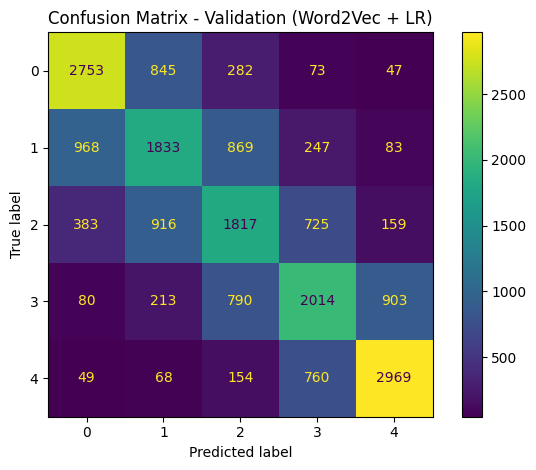

Test Accuracy: 0.579


In [23]:
import re
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------- helpers idénticos ----------
def _unwrap_base_dataset(ds):
    base = ds
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")
    base_custom = subset.dataset
    base_source = _unwrap_base_dataset(base_custom)
    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))
    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]
        y_i = int(subset[i]["y"])
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            text = str(row.get("text", "") or "")
        X.append(text)
        y.append(y_i)
    return X, y

# ---------- carga datos ----------
X_train, y_train = subset_to_xy_from_base(train_dataset)
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

# ---------- tokenizador ----------
_token_re = re.compile(r"[a-záéíóúüñ0-9]+(?:'[a-z0-9]+)?", re.IGNORECASE)
def tokenize(s: str):
    return _token_re.findall(s.lower())

sentences_tr = [tokenize(t) for t in X_train]

# ---------- Word2Vec ----------
w2v = Word2Vec(
    sentences=sentences_tr,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    negative=10,
    epochs=8,
    seed=42,
)

# ---------- texto -> vector (promedio simple) ----------
def doc_vector(tokens, model: Word2Vec):
    kv = model.wv
    vecs = [kv[tok] for tok in tokens if tok in kv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

def texts_to_matrix(texts, model: Word2Vec, batch_size=4096):
    out = np.zeros((len(texts), model.vector_size), dtype=np.float32)
    i = 0
    while i < len(texts):
        j = min(i + batch_size, len(texts))
        toks_batch = [tokenize(t) for t in texts[i:j]]
        for k, toks in enumerate(toks_batch):
            out[i + k] = doc_vector(toks, model)
        i = j
    return out

# ---------- vectorizar ----------
Xtr = texts_to_matrix(X_train, w2v)
Xva = texts_to_matrix(X_val,   w2v)
Xte = texts_to_matrix(X_test,  w2v)

print("Embeddings shape:", Xtr.shape, Xva.shape, Xte.shape)

# ---------- clasificador ----------
clf = LogisticRegression(
    max_iter=500,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1,
)
clf.fit(Xtr, y_train)

# ---------- evaluación ----------
pred_val = clf.predict(Xva)
acc_val = accuracy_score(y_val, pred_val)
print(f"\nWord2Vec(mean) + Logistic Regression | Val Accuracy: {acc_val:.4f}\n")
print(classification_report(y_val, pred_val, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation (Word2Vec + LR)")
plt.tight_layout()
plt.show()

pred_test = clf.predict(Xte)
print("Test Accuracy:", accuracy_score(y_test, pred_test))



Modelo lightgbm-Word2vec

Ejemplo: Cute and durable. Cute, good quality, packaged differently than the ones I’ve seen in stores. ... 4
Tamaños: 160000 20000 20000
Embeddings shape: (160000, 300) (20000, 300) (20000, 300)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.829060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 300
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.17329	valid_0's multi_error: 0.47915
[100]	valid_0's multi_logloss: 1.08771	valid_0's multi_error: 0.4591
[150]	valid_0's multi_logloss: 1.05035	valid

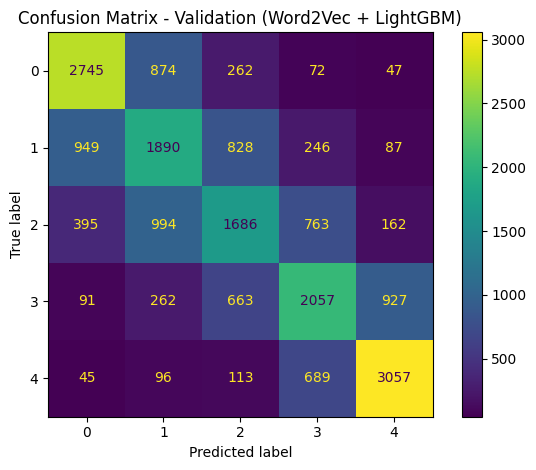

Word2Vec(mean) + LightGBM | Test Accuracy: 0.5701


In [24]:
# pip install gensim lightgbm

import re
import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt

# ================= Helpers para extraer X,y de tus Subset =================
def _unwrap_base_dataset(ds):
    """Desciende por atributos .dataset hasta llegar al dataset base (HF Dataset)."""
    base = ds
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    """
    Convierte un torch.utils.data.Subset -> (X, y).
      y: subset[i]['y'] (0..C-1)
      texto: del dataset base (HF) vía subset.indices -> 'review_title' + 'review_body'
    """
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")

    base_custom = subset.dataset
    base_source = _unwrap_base_dataset(base_custom)

    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))

    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]
        y_i = int(subset[i]["y"])
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            text = str(row.get("text", "") or "")
        X.append(text)
        y.append(y_i)
    return X, y

# ================= Construcción de X,y =================
X_train, y_train = subset_to_xy_from_base(train_dataset)
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

print("Ejemplo:", X_train[0][:120], "...", y_train[0])
print("Tamaños:", len(X_train), len(X_val), len(X_test))

# ================= Tokenizador simple =================
_token_re = re.compile(r"[a-záéíóúüñ0-9]+(?:'[a-z0-9]+)?", re.IGNORECASE)
def tokenize(s: str):
    return _token_re.findall(s.lower())

sentences_tr = [tokenize(t) for t in X_train]

# ================= Entrenar Word2Vec sobre TRAIN =================
# sg=1 (skip-gram) suele rendir mejor; ajusta vector_size/epochs según recursos
w2v = Word2Vec(
    sentences=sentences_tr,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    negative=10,
    epochs=8,
    seed=42,
)

# ================= Texto -> vector (promedio simple de embeddings) =================
def doc_vector(tokens, model: Word2Vec):
    kv = model.wv
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

def texts_to_matrix(texts, model: Word2Vec, batch_size=4096):
    out = np.zeros((len(texts), model.vector_size), dtype=np.float32)
    i = 0
    while i < len(texts):
        j = min(i + batch_size, len(texts))
        toks_batch = [tokenize(t) for t in texts[i:j]]
        for k, toks in enumerate(toks_batch):
            out[i + k] = doc_vector(toks, model)
        i = j
    return out

# ================= Vectorizar train/val/test con Word2Vec =================
Xtr = texts_to_matrix(X_train, w2v)
Xva = texts_to_matrix(X_val,   w2v)
Xte = texts_to_matrix(X_test,  w2v)

print("Embeddings shape:", Xtr.shape, Xva.shape, Xte.shape)

# ================= LightGBM (multiclase) =================
num_classes = len(np.unique(y_train))
clf = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,   # el wrapper suele inferirlo; lo dejamos explícito
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    subsample=0.9,           # bagging_fraction
    colsample_bytree=0.9,    # feature_fraction
    reg_lambda=1.0,
    n_jobs=-1,
)

# ================= Entrenamiento con early stopping (callbacks) =================
clf.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_val)],
    eval_metric=["multi_logloss", "multi_error"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

# ================= Métricas en validación =================
pred_val = clf.predict(Xva)
acc_val = accuracy_score(y_val, pred_val)
print(f"\nWord2Vec(mean) + LightGBM | Val Accuracy: {acc_val:.4f}\n")
print(classification_report(y_val, pred_val, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation (Word2Vec + LightGBM)")
plt.tight_layout()
plt.show()

# ================= (Opcional) Evaluación en test =================
pred_test = clf.predict(Xte)
acc_test = accuracy_score(y_test, pred_test)
print(f"Word2Vec(mean) + LightGBM | Test Accuracy: {acc_test:.4f}")


## LSTM

La siguiente  arquitectura LSTM funciona bien para clasificar reseñas porque es potente pero sencilla de entrenar: usar varias capas con dropout ayuda a que el modelo generalice mejor y, si se activa el modo bidireccional, puede captar relaciones en ambos sentidos del texto. Además, tomar hidden[-1] como salida es práctico y confiable, ya que resume toda la información de la secuencia en un solo vector que luego se usa fácilmente para clasificar.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, _) = self.lstm(embedded)
        return hidden[-1]


Este modelo usa una arquitectura LSTM + MLP que convierte cada reseña en una representación fija mediante el último estado oculto y luego la clasifica con capas densas y dropout. Se entrena con PyTorch Lightning, usando CrossEntropyLoss, Accuracy y AdamW para optimización. Es una configuración robusta porque combina la capacidad del LSTM para capturar dependencias secuenciales con regularización y un pipeline de entrenamiento estable

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, _) = self.lstm(embedded)
        return hidden[-1]

from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy


class comments_classifier(LightningModule):

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int, hidden_dim: int = 128):
        super(comments_classifier, self).__init__()
        self.num_classes = num_classes
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim, num_classes)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
            #nn.LogSoftmax(dim=1)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x):
        embeddings = self.lstm(x)
        return self.classifier(embeddings)


    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        # print(f"\nbatch-idx: {batch_idx}")
        # print(f"shape of x: {x.shape}")
        # print(torch.max(x, dim=0))
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x = batch['input_ids']
        return self(x)


    def configure_optimizers(self):
        optimizer =  torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer


model = comments_classifier(vocab_size=len(vocab) + 1, num_classes=5, emb_dim=32)

tb_logger = TensorBoardLogger('tb_logs', name='LSTMClassifier')
callbacks=[EarlyStopping(monitor='train-loss', patience=3, mode='min')]
use_gpu = torch.cuda.is_available()
trainer = Trainer(
    accelerator="gpu" if use_gpu else "cpu",
    devices=1,
    precision="16-mixed" if use_gpu else 32,
    max_epochs=1,
    logger=tb_logger,
    callbacks=callbacks
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | lstm       | LSTMBlock          | 1.5 M  | train
1 | classifier | Sequential         | 25.1 K | train
2 | train_acc  | MulticlassAccuracy | 0      | train
3 | val_acc    | M

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


In [ ]:
b = next(iter(train_loader))
print("input_ids:", b["input_ids"].shape, b["input_ids"].dtype)   # [B, L], torch.int64
print("y:", b["y"].shape, b["y"].dtype, b["y"].min().item(), b["y"].max().item())  # [B], int64, 0..4


input_ids: torch.Size([12, 128]) torch.int64
y: torch.Size([12]) torch.int64 0 4


In [ ]:
with torch.no_grad():
    out = model(b["input_ids"])
print("logits:", out.shape, out.dtype, out.min().item(), out.max().item())  # [B, 5]

logits: torch.Size([12, 5]) torch.float32 -0.29180896282196045 0.19137512147426605


In [ ]:
from torch.utils.data import Subset, DataLoader
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

# 1) subset pequeño
small_train = Subset(train_dataset, range(500))
small_val   = Subset(val_dataset, range(200))

sl = DataLoader(small_train, batch_size=64, shuffle=True)
sv = DataLoader(small_val,   batch_size=64, shuffle=False)

# 2) trainer rápido
use_gpu = torch.cuda.is_available()
trainer = Trainer(
    max_epochs=8,
    accelerator="gpu" if use_gpu else "cpu",
    devices=1,
    precision="16-mixed" if use_gpu else 32,
    callbacks=[EarlyStopping(monitor='val-loss', patience=2, mode='min')],
    enable_progress_bar=True
)

# 3) ENTRENAR
trainer.fit(model, train_dataloaders=sl, val_dataloaders=sv)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | lstm       | LSTMBlock          | 1.5 M  | train
1 | classifier | Sequential         | 25.1 K | train
2 | train_acc  | MulticlassAccuracy | 0      | train
3 | val_acc    | M

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.


Este código mide qué tan representativo es tu vocabulario y cuántas palabras de las reseñas quedaron fuera

In [ ]:
pad_id = vocab["[PAD]"]
unk_id = vocab["[UNK]"]

def stats_batch(batch):
    ids = batch["input_ids"]       # [B, L]
    real = (ids != pad_id)
    unk  = (ids == unk_id) & real
    real_tokens = real.sum().item()
    unk_tokens  = unk.sum().item()
    print(f"%%UNK entre tokens no-PAD: {unk_tokens / max(1,real_tokens):.2%}")

b = next(iter(train_loader))
stats_batch(b)


%%UNK entre tokens no-PAD: 0.00%


Se evidencia que ninguna palabra de las reseñas se quedaron por fuera en el entrenamiento.

In [ ]:
def pad_ratio_batch(batch):
    ids = batch["input_ids"]
    pad_ratio = (ids == pad_id).float().mean().item()
    print(f"PAD ratio (promedio en el batch): {pad_ratio:.2%}")

pad_ratio_batch(b)


PAD ratio (promedio en el batch): 61.65%


Este código mide qué tan distintos son los embeddings que genera el LSTM para cada ejemplo del batch.

In [ ]:
with torch.no_grad():
    feats = model.lstm(b["input_ids"].to(model.device))  # [B, H]
    diffs = (feats[1:] - feats[:-1]).abs().mean(dim=1).cpu().numpy()
    print("Dif media entre ejemplos consecutivos (primer batch):", diffs.mean())


Dif media entre ejemplos consecutivos (primer batch): 0.0028164103


Ese resultado significa que, en tu primer batch, las representaciones que genera el LSTM para ejemplos consecutivos son muy parecidas: la diferencia promedio es apenas 0.0028 (en un rango donde los valores de los embeddings suelen estar en torno a 0.1–1.0).

In [ ]:
print(model.classifier)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=128, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=64, out_features=5, bias=True)
)


Este bloque es la parte final del modelo, la que hace la clasificación.
Primero aplana la salida del LSTM, luego pasa por varias capas densas con ReLU y Dropout (para aprender mejor y evitar sobreajuste), y al final saca un vector de tamaño 5, que corresponde a las clases posibles de las reseñas.

In [ ]:
# ================== Imports necesarios ==================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping
from torchmetrics import Accuracy

# (opcional) pequeñas mejoras de rendimiento
torch.backends.cudnn.benchmark = True

# ================== Bloque LSTM con packing ==================
class LSTMBlockPacked(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=1, dropout=0.2, padding_idx=0,
                 bidirectional=True, emb_dropout=0.1):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.out_dim = hidden_dim * (2 if bidirectional else 1)

    def forward(self, x, lengths):
        # x: [B, L], lengths: [B] (número de tokens != PAD)
        emb = self.emb_dropout(self.embedding(x))
        lengths_cpu = lengths.to("cpu")
        packed = pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)  # [B, L_eff, D]

        # Global max-pooling sobre pasos válidos
        B, L_eff, D = out.size()
        device = out.device
        mask = (torch.arange(L_eff, device=device)[None, :] < lengths[:, None])  # [B, L_eff]
        out_masked = out.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        feats = out_masked.max(dim=1).values  # [B, D]
        return feats

# ================== LightningModule ==================
class CommentsClassifier(pl.LightningModule):
    def __init__(self, vocab_size, num_classes, emb_dim=128, hidden_dim=64, pad_id=0):
        super().__init__()
        self.save_hyperparameters()
        self.pad_id = pad_id

        self.lstm = LSTMBlockPacked(
            vocab_size=vocab_size,
            embed_dim=emb_dim,
            hidden_dim=hidden_dim,
            padding_idx=pad_id,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(self.lstm.out_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes)  # logits crudos
        )

        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc   = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        lengths = (x != self.pad_id).sum(dim=1)          # [B]
        feats = self.lstm(x, lengths)                    # [B, H*D]
        logits = self.classifier(feats)                  # [B, C]
        return logits

    def training_step(self, batch, _):
        x, y = batch["input_ids"], batch["y"]            # y: int64 en [0..C-1]
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log("train-loss", loss, prog_bar=True, on_epoch=True)
        self.log("train-acc", self.train_acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, _=None):
        x, y = batch["input_ids"], batch["y"]
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log("val-loss", loss, prog_bar=True, on_epoch=True)
        self.log("val-acc", self.val_acc, prog_bar=True, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)

# ================== Instanciación segura y Trainer ==================
pad_id = vocab.get("[PAD]", 0)          # usa el PAD real de tu vocab
num_classes = 5                         # estrellas 1..5 mapeadas a 0..4
use_gpu = torch.cuda.is_available()

model = CommentsClassifier(
    vocab_size=len(vocab),               # NO sumes +1 si ya trae especiales
    num_classes=num_classes,
    emb_dim=128,                         # puedes subir a 256 si hay memoria
    hidden_dim=64,
    pad_id=pad_id
)

tb_logger = TensorBoardLogger('tb_logs', name='LSTMClassifier')
callbacks = [EarlyStopping(monitor='val-loss', patience=7, mode='min')]

trainer = Trainer(
    accelerator="gpu" if use_gpu else "cpu",
    devices=1,
    precision="16-mixed" if use_gpu else 32,
    max_epochs=15,                        # 1 época suele quedar en ~azar; usa 3–5
    logger=tb_logger,
    callbacks=callbacks
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | lstm       | LSTMBlockPacked    | 5.2 M  | train
1 | classifier | Sequential         | 10.5 K | train
2 | train_acc  | MulticlassAccuracy | 0      | train
3 | val_acc    | M

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Conclusiones:


El análisis mostró que la forma de representar el texto es más determinante que el modelo en sí. Al comparar enfoques, los modelos basados en TF-IDF tuvieron un desempeño claramente superior a los que usaban promedios de Word2Vec, lo que evidencia que en este dataset las frecuencias de palabras contienen la señal más valiosa.

A pesar de probar distintos algoritmos, el resultado más sólido lo dio un modelo sencillo: Logistic Regression con TF-IDF, que alcanzó una accuracy cercana al 0.605. Esto demuestra que, en este caso, los modelos simples pueden superar en eficacia a alternativas más complejas como LightGBM o redes neuronales.

Se observó también un comportamiento desigual entre clases: las clases 0 y 4 fueron predichas con buena precisión y recall, mientras que las clases 1 y 2 resultaron más difíciles de distinguir, revelando una clara asimetría en el desempeño.

En términos generales, los modelos se mantuvieron en un rango de 0.57 a 0.61 de accuracy, lo que marca un límite de rendimiento con las configuraciones probadas.

Por otro lado, la LSTM quedó muy por debajo (≈0.23 de accuracy), lo que refleja tanto las limitaciones de cómputo como la necesidad de mayor entrenamiento.

Finalmente, el intento de usar XGBoost no pudo completarse debido a la exigencia de recursos del dataset, lo que refuerza la idea de que la complejidad del problema requiere cuidado no solo en el modelado, sino también en la infraestructura.
